# Oracle Sketching and dimensional reduction #

Intro goes here...

## Oracle sketching for IID data ##

We start with the toy case from the paper, Algorithm 1 from section D.2. The setup is that we have 	$M$ data samples $(x_i,f(x_i))$ for $f \colon [N] \to \left\{0,1 \right\}$. The paper also includes a probability distribution $p(x)$ on $[N]$, but for now we take the uniform distribution $p(x) = 1/N$.

In this case, the sketching Oracle is a circuit that implements the gate 
$V = \prod_{i=1}^M V_i$, where 
$$
 V_i = \exp \left( i \frac{y_i t}{M} | x_i \rangle \langle x_i | \right). 
$$
to construct the phase oracle 
$ O = \sum_{x=1}^N (-1)^{f(x)}| x_i \rangle \langle x_i |$, we would set $t = M \pi$.

In [129]:
import qiskit.circuit
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, ClassicalRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, PauliGate, UnitaryGate, StatePreparation
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import qiskit.quantum_info as qi
from qiskit.quantum_info import Operator, Statevector, DensityMatrix, Pauli, random_density_matrix
from qiskit import transpile

from IPython.display import display, Image, Markdown, Latex
import matplotlib.pyplot as plt
import numpy as np
import math
import scipy.stats

from qiskit_aer import AerSimulator


In [121]:
def format_matrix(matrix):
    """Format a matrix using LaTeX syntax"""
    body_lines = [" & ".join(map(str, row))+' \\\\' for row in matrix] 
    body = '\\begin{pmatrix} \n'+'\n'.join(body_lines) + '\n\\end{pmatrix}'
    return body

First let's create a Boolean function on $[N]$ and then take $M$ independent samples from it.

In [29]:
N = 16
M=8

domain = np.arange(N)
outputs = [np.random.randint(0,2) for i in range(N)]
true_binary_function = np.array(list(zip(domain,outputs))) #represent f as an N x 2 array
true_binary_function


array([[ 0,  0],
       [ 1,  0],
       [ 2,  1],
       [ 3,  1],
       [ 4,  0],
       [ 5,  1],
       [ 6,  1],
       [ 7,  0],
       [ 8,  1],
       [ 9,  0],
       [10,  1],
       [11,  1],
       [12,  1],
       [13,  1],
       [14,  0],
       [15,  0]])

In [30]:
binary_samples = np.zeros((M,2))

for k in range(M):
    index = np.random.randint(0,N)
    binary_samples[k] = true_binary_function[index,:]

binary_samples

array([[ 8.,  1.],
       [ 6.,  1.],
       [15.,  0.],
       [ 0.,  0.],
       [ 3.,  1.],
       [ 4.,  0.],
       [ 1.,  0.],
       [ 2.,  1.]])

In [31]:
len(binary_samples)

8

Now we create a quantum circuit to implement the phase oracle based on the sample data. We also need to know the value $[N]$, which is the `domain_size` variable in our function. The `sample_data` should come in the form of an $M \times 2$ array. Note that we implement each $V_i$ as a multicontrolled phase, with control $|x_i \rangle \langle x_i|$> and phase $t/M$. One can check easily from the definition of the exponential map that $V_i$ acts as identity on all other qubits.

In [32]:
# #Old junk version

# def oracle_circuit(domain_size, sample_data, time):
#     ''' Implements Algorithm 1: Quantum Oracle sketching as described above. Outputs appropriate QuantumCircuit object'''

#     num_qubits = int(math.ceil(math.log2(domain_size)))
#     quantum_register = QuantumRegister(num_qubits,name='q')
#     ancilla_register = AncillaRegister(1,name='a')

#     oracle_circuit = QuantumCircuit(quantum_register,ancilla_register)

#     oracle_circuit.x(ancilla_register) #So that ancilla can be affected by control
    
#     for i in range(len(sample_data)):
#         if int(sample_data[i][1]) == 1:
#             oracle_circuit.mcp(time/len(sample_data), control_qubits = quantum_register, target_qubit = ancilla_register, ctrl_state=int(sample_data[i][0]))

#     oracle_circuit.x(ancilla_register)

#     return oracle_circuit

In [33]:
 # Diagonal gate version
#  def oracle_circuit(domain_size, sample_data, time):
#     ''' Implements Algorithm 1: Quantum Oracle sketching as described above. Outputs appropriate QuantumCircuit object'''

#     num_qubits = int(math.ceil(math.log2(domain_size)))
#     quantum_register = QuantumRegister(num_qubits,name='q')

#     oracle_circuit = QuantumCircuit(quantum_register)   
    
#     sample_size = len(sample_data)

#     for i in range(sample_size):
#         phases  = np.zeros(2**num_qubits)
#         phases[int(sample_data[i][0])] = time*sample_data[i][1]/sample_size
#         diag = np.exp(1j*phases)
#         V_gate = DiagonalGate(diag)
#         V_gate.name = rf"$V_{i}$"
#         oracle_circuit.append(V_gate, qargs=quantum_register[:])
#     return oracle_circuit

In [34]:
# Multicontrolled phase version
def oracle_circuit(domain_size, sample_data, time):
    ''' Implements Algorithm 1: Quantum Oracle sketching as described above. Outputs appropriate QuantumCircuit object'''

    num_qubits = int(math.ceil(math.log2(domain_size)))
    quantum_register = QuantumRegister(num_qubits,name='q')

    oracle_circuit = QuantumCircuit(quantum_register)   
    
    sample_size = len(sample_data)

    for i in range(sample_size):
        if int(sample_data[i][1]) == 1:
            target_state = int(sample_data[i][0])
            target_string = f'{target_state:0{num_qubits}b}'[::-1] #Reversed for Little Endian
            oracle_circuit.barrier()
            for k in range(num_qubits):
                if target_string[k] == '0':
                    oracle_circuit.x(quantum_register[k])
            oracle_circuit.barrier()
            oracle_circuit.mcp(time/sample_size, control_qubits = quantum_register[1:], target_qubit = quantum_register[0])
            oracle_circuit.barrier()
            for k in range(num_qubits):
                if target_string[k] == '0':
                    oracle_circuit.x(quantum_register[k])
    return oracle_circuit

In [35]:
num_qubits = 6
target_state = 14
target_string = f'{target_state:0{num_qubits}b}'
print(target_string,target_string[-2])
# for k in range(num_qubits):
#     print( target_string[-k] == '0')

001110 1


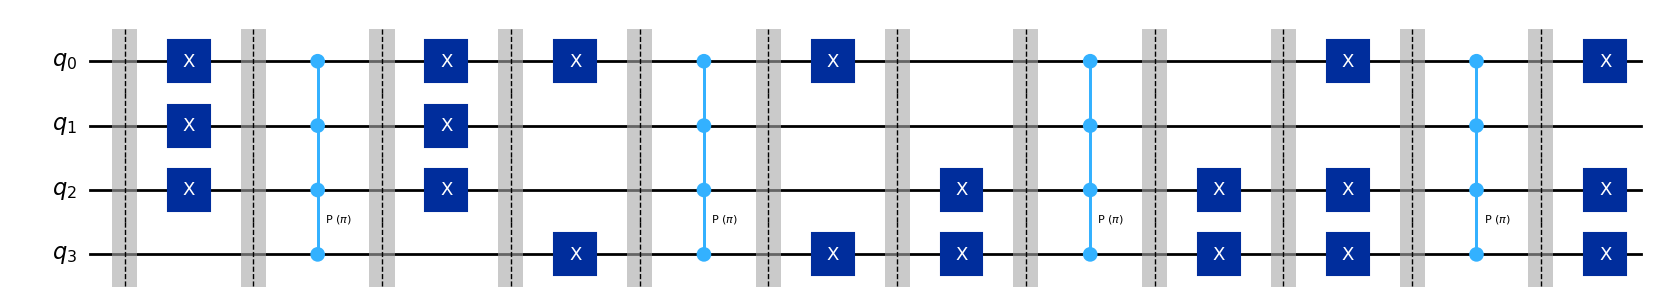

In [36]:
oracle_example = oracle_circuit(N,binary_samples, M*np.pi)
oracle_example.draw(output='mpl')

In [37]:
#Troubleshooting

bitcount = int(math.ceil(np.log2(N)))

bad_counter = 0
good_counter = 0
for k in range(M):

    state = int(binary_samples[k][0])
    # print('k=',k,'state=',state)
    state_gate = StatePreparation(state,bitcount)

    test_circuit = QuantumCircuit(bitcount+1)
    test_circuit.compose(state_gate, inplace=True)
    test_circuit.compose(oracle_example, inplace=True)
    test_circuit.draw(output="mpl")
    psi = Statevector(test_circuit)
    # print('entry=',np.round(psi.data[state],5))
    check1 = np.isclose(psi.data[state],[-1],atol=1e-5) 
    check2 = np.isclose(psi.data[state],[1],atol=1e-5) # If neither are true then the rotation is wrong!
    if check1 and int(binary_samples[k][1]) == 0:
        print(f'something has gone wrong with state {state}!!!!')
        bad_counter += 1
        # print(f'state {state} WAS rotated','f(x)=',binary_samples[k][1])
    if check1 and int(binary_samples[k][1])== 1:
        good_counter += 1
    if check2 and int(binary_samples[k][1])== 1:
        print(f'{state} is unchanged, but appeared in our sample {(binary_samples[:,0:1] == state).sum()} times')
        if (binary_samples[:,0:1] == state).sum() % 2 == 1:
            print(f'something has gone wrong with state {state} :(')
            bad_counter += 1
        good_counter += 1
    if check2 and int(binary_samples[k][1]) == 0:
        good_counter += 1
    if not check1 and not check2:
        print(f'state {state} was sent to', psi.data)
        bad_counter += 1

if good_counter != M:
    print(f'WARNING: only checked {good_counter} of {M} states')
if bad_counter == 0:
    print('no issues detected! :)')


no issues detected! :)


## Multi-bit version ##

In this case, we have a function $f \colon [N] \to \{ 0,1 \}^b$. The idea is that we store states as $|x \rangle | b  \rangle $, because we can think of $f$ as a subset of $[N] \times [b]$ instead of a function $[N] \to \{ 0,1 \} \times [b]$. The algorithm is the same, except that for each sample $(x_i,y_i)$ we apply
$$ V_{i,j} = \exp \left( \frac{it (y_i)_j}{M} | x_i, j \rangle \langle x_i, j | \right), $$
which is the same idea as before, except now we have $N + \log_2(b)$ qubits instead of $N$. Note that superposition and binary expansion is used to efficiently store the output of the function. $|x_i, j \rangle \langle x_i, j |$ gets flipped iff the $j$ th bit of $f(x_i)$ is 1.

By applying all of our $V_{i,j}$ gates for a random sample of $(x_i,y_i)'s$, we are approximating the unitary

$$
U = \sum_{x,j} e^{i p(x) f_j(x) t} |x, j \rangle \langle x, j |,
$$
where $p(x)$ is the probability of choosing $x$ when sampling. Lemma D.15 in the paper tells us that we at worst need $\Omega(t^2 p_{max}/\varepsilon)$ samples to $\varepsilon$-approximate $U$ in diamond norm, where $p_{max}$ maximum value of $p(x)$. Note that if we want to implement a phase flip oracle for a uniform distribution, we would need $t = N \pi$ so that $\Omega(N/\varepsilon)$ samples are required.

Important convention to note: the conversion from values of $|j \rangle$ to $f(x)$ is such that the value $|0 \rangle$ on the '$b$' register corresponds to the *least* significant digit of the binary expansion of $j$. So the state $|x_i, 0 \rangle $ being flipped would tell us that the binary representation of $f(x_i)$ is of the form $(... 1)$ in Big endian notation. Conversely, if the least significant bit is $0$, then the state $|x_i, 0 \rangle$ is unchanged by the sketching oracle.


In [38]:
# Multicontrolled phase version
def multi_oracle_circuit(domain_size, codomain_size, sample_data, time):
    ''' Implements Algorithm 1: Quantum Oracle sketching as described above. Outputs appropriate QuantumCircuit object. 
    Underlying function from [domain_size] -> [codomain_size].'''

    # print('domain_size=',domain_size)
    # print('codomain_size=',codomain_size)
    bit_length = int(math.ceil(math.log2(codomain_size)))
    # print('bit_length=',bit_length)

    num_qubits_x = int(math.ceil(math.log2(domain_size)))
    num_qubits_b = int(math.ceil(math.log2(bit_length)))
    # print('num_qubits_b=',num_qubits_b)

    quantum_register_x = QuantumRegister(num_qubits_x,name='x')
    quantum_register_b = QuantumRegister(num_qubits_b,name='b')

    oracle_circuit = QuantumCircuit(quantum_register_x,quantum_register_b)   
    
    sample_size = len(sample_data)

    for i in range(sample_size):
        if int(sample_data[i][1]) != 0:
            
            target_state_x = int(sample_data[i][0])
            target_string_x = f'{target_state_x:0{num_qubits_x}b}'[::-1]

    
            target_state_b = int(sample_data[i][1])
            target_string_b = f'{target_state_b:0{bit_length}b}'[::-1]
            print(f'f({target_state_x}) = {target_state_b}')
            print('binary=',target_string_x,target_string_b)

            for m in range(num_qubits_x): # send x_i to all 1s
                if int(target_string_x[m]) == 0:
                        oracle_circuit.x(quantum_register_x[m])

            oracle_circuit.barrier()

            for k in range(bit_length): # iterate over all possible states the b_register can be in
                y_i_j = int(target_string_b[k]) #tells us phase
                k_string = f'{k:0{num_qubits_b}b}'[::-1]
                # print('k=',k,'k_string=',k_string)
                for l in range(num_qubits_b): # swap k to all 1s
                    if int(k_string[l]) == 0:
                        oracle_circuit.x(quantum_register_b[l])

                oracle_circuit.mcp(time*y_i_j/sample_size, control_qubits = quantum_register_x[:] + quantum_register_b[:-1], target_qubit = quantum_register_b[-1])

                for l in range(num_qubits_b): # swap 1 back to k
                    if int(k_string[l]) == 0:
                        oracle_circuit.x(quantum_register_b[l])

                oracle_circuit.barrier()

            for m in range(num_qubits_x): # swap 1 back to x_i
                if int(target_string_x[m]) == 0:
                        oracle_circuit.x(quantum_register_x[m])
        oracle_circuit.barrier()
        oracle_circuit.barrier()

    return oracle_circuit

In [39]:
domain_size = 16
codomain_size = 8
sample_size = 8

inputs = np.arange(domain_size)
outputs = [np.random.randint(0,codomain_size) for i in range(domain_size)]
true_function = np.array(list(zip(inputs,outputs))) #represent f as an N x 2 array
print('true function is')
print(true_function)

true function is
[[ 0  6]
 [ 1  5]
 [ 2  2]
 [ 3  3]
 [ 4  5]
 [ 5  3]
 [ 6  3]
 [ 7  5]
 [ 8  1]
 [ 9  6]
 [10  2]
 [11  1]
 [12  5]
 [13  3]
 [14  1]
 [15  7]]


In [40]:
samples = np.zeros((sample_size,2))

for k in range(sample_size):
    index = np.random.randint(0,domain_size)
    samples[k] = true_function[index,:]

samples

array([[ 4.,  5.],
       [10.,  2.],
       [15.,  7.],
       [ 3.,  3.],
       [ 2.,  2.],
       [ 7.,  5.],
       [10.,  2.],
       [ 5.,  3.]])

f(4) = 5
binary= 0010 101
f(10) = 2
binary= 0101 010
f(15) = 7
binary= 1111 111
f(3) = 3
binary= 1100 110
f(2) = 2
binary= 0100 010
f(7) = 5
binary= 1110 101
f(10) = 2
binary= 0101 010
f(5) = 3
binary= 1010 110


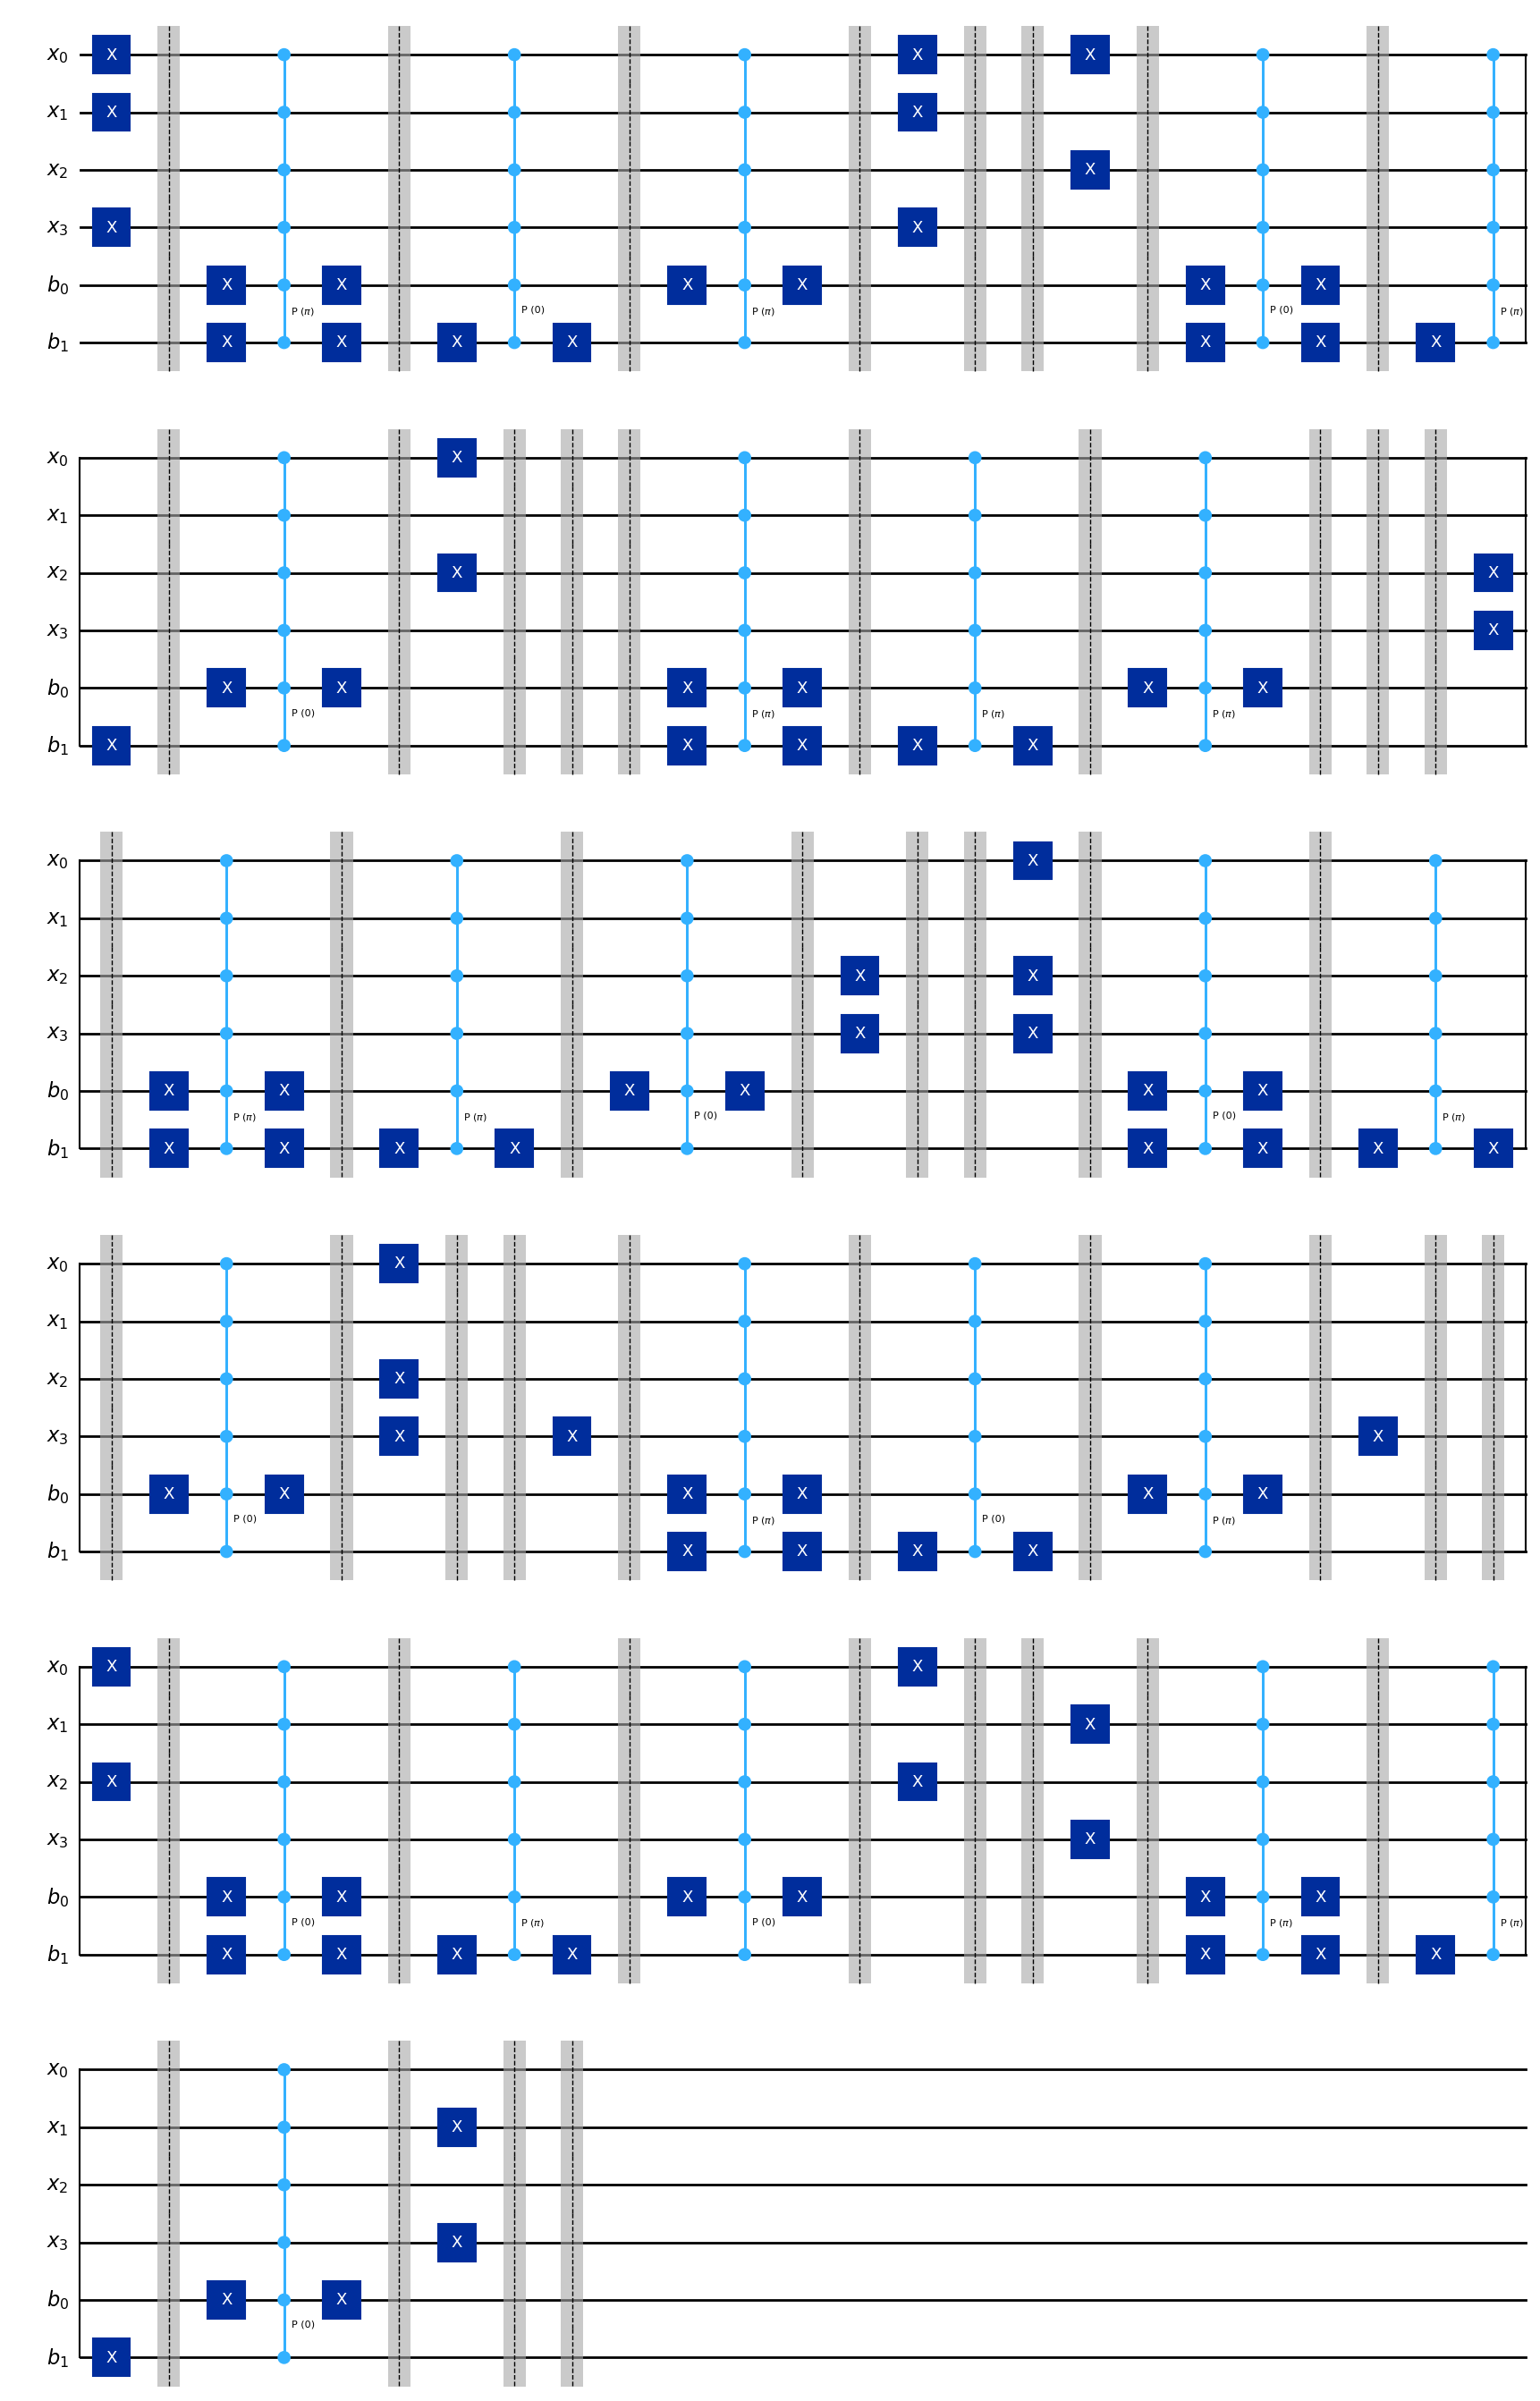

In [41]:
multi_oracle_example = multi_oracle_circuit(domain_size,codomain_size,samples, len(samples)*np.pi)
multi_oracle_example.draw(output='mpl')

In [42]:
# Test it!
# 4 = 0010
# codomain size = 8
# so b = 3
# so we store in 2 bits 
psi_array = []

for i in range(len(samples)):

    xreg = QuantumRegister(4,name="x")
    breg = QuantumRegister(2,name="b")
    test_circuit = QuantumCircuit(xreg, breg)
    test_circuit.h(breg)

    #prepare input state with sample x_i
    sample_input = int(samples[i][0])
    # print('x_i=',sample_input)
    initial_string = f'{sample_input:0{4}b}'[::-1]
    # print('x_i string=',initial_string)
    
    for j in range(len(initial_string)):
        if initial_string[j] == '1':
            test_circuit.x(xreg[j])
    
    test_circuit.barrier()
    test_circuit.compose(multi_oracle_example, inplace=True)

    psi = Statevector(test_circuit)
    psi_array.append(psi)

In [43]:
#Signs can be used to read off the bits of f(x): so e.g. +|11...> - |10...>  + |01...> - |00...> corresponds to binary string 0101 meaning that f(x) = 5, as can be seen with the example of where
#  |15>|+> gets sent to by our oracle circuit 

for i in range(len(psi_array)):
    display(f'{int(samples[i][0])} gets send to',psi_array[i].draw('latex'))

'4 gets send to'

<IPython.core.display.Latex object>

'10 gets send to'

<IPython.core.display.Latex object>

'15 gets send to'

...

<IPython.core.display.Latex object>

'10 gets send to'

<IPython.core.display.Latex object>

'5 gets send to'

<IPython.core.display.Latex object>

## Application: Dimensional Reduction

We follow section F.3. given the data matrix $X$, we form $H = -X X^T$. The algorithm is essentially as follows:

- Construct a circuit that approximates $|w \rangle$, the largest eigenvector of $H$.
- To estimate $\xi'_i \cdot w$ for some arbitrary unit vector $\xi'_i$, prepare the state $|xi'_i \rangle$ and apply the above circuit to it. 
- Use shadow tomography to estimate the observable $O(\xi'_i)$, where $O(\xi'_i) = \xi'_i \cdot w$.

The speedup comes from the following: There is already a proof for preparing $|w \rangle$ given Hermitian $H$, with gates and queries inversely proportional to $\Delta$, the gap between the largest two eigenvalues. However, instead of using block encoding of $H$, oracle sketching is used to implement an approximate block-encoding of $H$ in $O(RN\rho^5)$ samples, where $\rho$ is the sparsity parameter, $N = 2^n$ is the largest dimension of the data matrix, while $R$ is the repetition number (look this up). Therefore, we first need to construct algorithms for:

- Sparse oracles (needed for block encoding).
- Block encoding of sparse matrices.
- Preparation of quantum states (to prepare $\xi'_i$).

As detailed in section D.5 of the paper.

## Sparse Oracle Sketching

Sparse Oracle: $A$ is matrix with row sparsity $s_r$ and column sparsity $s_c$. The maximum of $s_r,s_c$ is denoted by $s$. There are 3 sparse oracles:
	$$
	\begin{alignedat}{2}
		O_A^{\text{ele}} &\colon | i \rangle | j \rangle | 0 \rangle_b &&\mapsto |i \rangle | j \rangle |A_{ij} \rangle \\
		O_A^{\text{ind,row}} &\colon | i \rangle | k \rangle &&\mapsto |i \rangle | j(i,k) \rangle \\
		O_A^{\text{ind,col}} &\colon | j \rangle | k \rangle &&\mapsto |j \rangle  | i(j,k) \rangle,
	\end{alignedat}
	$$
	where $j(i,k) \in [N]$ encoded as $n-$bitstring is the index of the column where the $k \in [s_r]$'th non-zero element in row $i$ appears, and $i(j,k)$ is the index of the row where the \(k \in [s_c]\)'th non-zero element in row $j$ appears.
		We begin with the implementation of $O_A^{\text{ele}}$.


In [58]:
#build our random sparse matrix
matrix_dimension = 8
bitlength = 2

np.random.seed(seed=210)

# #Create zero matrix

sparse_matrix1 = np.zeros((matrix_dimension,matrix_dimension))

row_sparsity = 1/2 #proportion of nonzero entries in each row
nonzero_entry_number = int(row_sparsity*matrix_dimension)

#add non-zero entries matrix
row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)
col_nonzero_counts = np.count_nonzero(sparse_matrix1 , axis=0)

for j in range(matrix_dimension):
    while row_nonzero_counts[j]  < nonzero_entry_number:
        sparse_matrix1[j][np.random.choice(np.arange(matrix_dimension))] = np.random.randint(2**bitlength)
        row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)
col_nonzero_counts = np.count_nonzero(sparse_matrix1 , axis=0)
for k in range(matrix_dimension):
    while col_nonzero_counts[k]  > nonzero_entry_number:
        sparse_matrix1[np.random.choice(np.arange(matrix_dimension))][k] = 0
        col_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=0)
row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)

sparse_matrix1 = sparse_matrix1.astype(int)
support_size = np.count_nonzero(sparse_matrix1)
sparse_matrix1

array([[0, 2, 0, 2, 3, 0, 0, 3],
       [2, 0, 0, 0, 0, 1, 2, 0],
       [0, 0, 0, 0, 3, 3, 0, 2],
       [2, 0, 1, 0, 0, 2, 0, 0],
       [0, 2, 1, 0, 0, 0, 3, 1],
       [0, 0, 0, 1, 2, 0, 3, 0],
       [3, 3, 0, 2, 0, 0, 0, 1],
       [0, 2, 3, 0, 3, 1, 0, 0]])

In [59]:
#implement data streaming process on sparse matrix
def sparse_element_stream(sparse_matrix,seednum=100):
    ''' Uniformly randomly picks an index (i,j) such that A_{ij} != 0
    and returns [i, j, A_{ij}] along with size of sample space'''
    np.random.seed(seednum)
    support_size = np.count_nonzero(sparse_matrix)
    # for index, x in np.ndenumerate(sparse_matrix):
    #     print(index,x)
    support_indices = np.nonzero(sparse_matrix.astype(int))

    index = np.random.randint(0,support_size)
    sample=[int(support_indices[0][index]),int(support_indices[1][index]),int(sparse_matrix[support_indices[0][index],support_indices[1][index]])]
    return sample


In [60]:
stream = sparse_element_stream(sparse_matrix1)
print(stream)
if stream[2] == sparse_matrix1[stream[0], stream[1]]:
    print('sample is correct')
else:
    print('sample is wrong')

[2, 5, 3]
sample is correct


In [ ]:
# Element oracle on above sparse matrix

# Start with U_a for a=0: should flip only iff odd entry in matrix
num_qubits = math.ceil(np.log2(matrix_dimension))

qr_row = QuantumRegister(num_qubits,name='q_row')
qr_col = QuantumRegister(num_qubits,name='q_col')
qr_entry = QuantumRegister(bitlength,name='q_entry')
element_oracle_circuit = QuantumCircuit(qr_row,qr_col,qr_entry)

K = np.count_nonzero(sparse_matrix1) #size of sample space
sample_number = 1000*K

sample_array = []

seednumber = 0

#initialize |0> to |-> so that controlled phase marking yields |-> when undoing.
element_oracle_circuit.x(qr_entry)
element_oracle_circuit.h(qr_entry) 

for m in range(sample_number):
    rsample = sparse_element_stream(sparse_matrix1,seednumber) 
    seednumber += 1
    sample_array.append(rsample)
    for k in range(bitlength):
        element_oracle_circuit.x(qr_entry[k])
        # sample_number_array[rsample[0],rsample[1]] += 1

        row_bitstring = f'{rsample[0]:0{num_qubits}b}'
        col_bitstring = f'{rsample[1]:0{num_qubits}b}'
        element_bitstring = f'{rsample[2]:0{bitlength}b}'[::-1]

        index_bitstring = col_bitstring+row_bitstring #mcp control state reads right to left (big endian)
        #Apply random unitary V_a(i,j) for A_{i,j} bitwise on entry register

        bitint = int(element_bitstring[k])
        element_oracle_circuit.mcp(np.pi*K*bitint/sample_number,control_qubits=qr_row[:]+qr_col[:],target_qubit=qr_entry[k],ctrl_state= index_bitstring)

        element_oracle_circuit.x(qr_entry[k])

element_oracle_circuit.h(qr_entry)
element_oracle_circuit.x(qr_entry)


element_oracle_gate = element_oracle_circuit.to_gate()

In [227]:
def element_oracle_gate(matrix, samples: int, startingseed=0, sampleabsolute=False):
    ''' Element oracle for given sparse matrix with specified sample count.
    Sample count will be (number of nonzero entries)*(samples) unless sampleabsolute=True'''
    matrix_dimension = len(matrix)

    num_qubits = math.ceil(np.log2(matrix_dimension))
    bitlength = math.ceil(np.log2(np.max(matrix)+1))

    qr_row = QuantumRegister(num_qubits,name='q_row')
    qr_col = QuantumRegister(num_qubits,name='q_col')
    qr_entry = QuantumRegister(bitlength,name='q_entry')
    element_oracle_circuit = QuantumCircuit(qr_row,qr_col,qr_entry)

    K = np.count_nonzero(matrix) #size of sample space

    seednumber = startingseed

    if sampleabsolute:
        sample_number = samples
    else:
        sample_number = int(K*samples)

    #initialize |0> to |-> so that controlled phase marking yields |-> when undoing.
    element_oracle_circuit.x(qr_entry)
    element_oracle_circuit.h(qr_entry) 

    for m in range(sample_number):
        rsample = sparse_element_stream(matrix,seednum=seednumber) 
        seednumber += 1

        for k in range(bitlength):
            # element_oracle_circuit.x(qr_entry[k])

            row_bitstring = f'{rsample[0]:0{num_qubits}b}'
            col_bitstring = f'{rsample[1]:0{num_qubits}b}'
            element_bitstring = f'{rsample[2]:0{bitlength}b}'[::-1]

            index_bitstring = col_bitstring+row_bitstring #mcp control state reads right to left (big endian)
            #Apply random unitary V_a(i,j) for A_{i,j} bitwise on entry register

            bitint = int(element_bitstring[k])
            element_oracle_circuit.mcp(np.pi*K*bitint/sample_number,control_qubits=qr_row[:]+qr_col[:],target_qubit=qr_entry[k],ctrl_state= index_bitstring)

            # element_oracle_circuit.x(qr_entry[k])

    element_oracle_circuit.h(qr_entry)
    element_oracle_circuit.x(qr_entry)

    return element_oracle_circuit

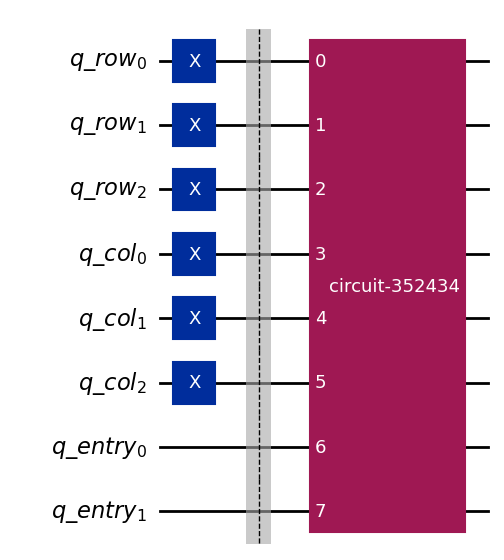

In [67]:
qr_row = QuantumRegister(num_qubits,name='q_row')
qr_col = QuantumRegister(num_qubits,name='q_col')
qr_entry = QuantumRegister(bitlength,name='q_entry')
test_circuit = QuantumCircuit(qr_row,qr_col,qr_entry)

test_circuit.x(qr_row[1])
test_circuit.x(qr_col[1])

row_bitstring = f'{index:0{num_qubits}b}'
col_bitstring = f'{index:0{num_qubits}b}'
state_bitstring = col_bitstring + row_bitstring

#prepare input state with sample x_i
sample_input = int(samples[i][0])
# print('x_i=',sample_input)
initial_string = f'{sample_input:0{4}b}'[::-1]
# print('x_i string=',initial_string)
for i in range(num_qubits):
    if row_bitstring[i] == '1':
        test_circuit.x(qr_row[i])
for j in range(num_qubits):
    if col_bitstring[j] == '1':
        test_circuit.x(qr_col[j])


test_circuit.barrier()
test_circuit.append(element_oracle_gate,qr_row[:]+qr_col[:]+qr_entry[:])

display(test_circuit.draw(output='mpl'))

In [68]:
for i in range(5,6):
    print(i)

5


In [69]:
phase = np.pi*K/sample_number
print('phase=', phase )
for i in range(matrix_dimension): #fix row
    for j in range(matrix_dimension): #go across row
        entry = int(sparse_matrix1[i][j])
        # print('k=',k,'state=',state)
        rowstate_gate = StatePreparation(i,num_qubits)
        colstate_gate = StatePreparation(j,num_qubits)

        tensor_state = i + 2**num_qubits*j

        qr_row = QuantumRegister(num_qubits,name='q_row')
        qr_col = QuantumRegister(num_qubits,name='q_col')

        test_circuit = QuantumCircuit(qr_row,qr_col,qr_entry)
        test_circuit.compose(rowstate_gate,qubits=qr_row, inplace=True)
        test_circuit.compose(colstate_gate,qubits=qr_col, inplace=True)
        test_circuit.compose(element_oracle_gate, inplace=True)
        # display(f'i={i} , j={j}')
        # display('state=',tensor_state)
        psi = Statevector(test_circuit)
        # display('state=',psi.draw('latex'))
        # print('entry=',np.round(psi.data[state],5))
        print(f'statevector for {i},{j} is...') 
        display(psi.draw('latex'))
        # check1 = np.isclose(psi.data[tensor_state],[np.exp(phase*1j)],atol=1e-5) 
        # # check2 = np.isclose(psi.data[tensor_state],[1],atol=1e-5) # If neither are true then the rotation is wrong!
        # if check1 == True:
        #     print(f'|{i},{j}> rotated', 'matrix entry =', entry)
        # elif check2 == True:
        #     print(f'|{i},{j}>  not rotated', 'matrix entry =', entry)
        # if check1 and int(binary_samples[k][1]) == 0:
        #     print(f'something has gone wrong with state {state}!!!!')
        #     bad_counter += 1
        #     # print(f'state {state} WAS rotated','f(x)=',binary_samples[k][1])
        # if check1 and int(binary_samples[k][1])== 1:
        #     good_counter += 1
        # if check2 and int(binary_samples[k][1])== 1:
        #     print(f'{state} is unchanged, but appeared in our sample {(binary_samples[:,0:1] == state).sum()} times')
        #     if (binary_samples[:,0:1] == state).sum() % 2 == 1:
        #         print(f'something has gone wrong with state {state} :(')
        #         bad_counter += 1
        #     good_counter += 1
        # if check2 and int(binary_samples[k][1]) == 0:
        #     good_counter += 1
        # if not check1 and not check2:
        #     print(f'state {state} was sent to', psi.data)
        #     bad_counter += 1



phase= 0.3141592653589793
statevector for 0,0 is...


<IPython.core.display.Latex object>

statevector for 0,1 is...


<IPython.core.display.Latex object>

statevector for 0,2 is...


...

<IPython.core.display.Latex object>

statevector for 7,6 is...


<IPython.core.display.Latex object>

statevector for 7,7 is...


<IPython.core.display.Latex object>

In [ ]:

def guess_matrix(sparsematrix,samples=25,startingseed=0,sampleabsolute=False, rounding=None):
    
    matrix_dim = len(sparsematrix)
    num_qubits = int(np.log2(len(sparsematrix)))
    reconstructed_matrix = np.zeros((matrix_dim,matrix_dim))
    reconstructed_variance = np.zeros((matrix_dim,matrix_dim))

    bitlength = math.ceil(np.log2(np.max(sparsematrix)+1))

    element_oracle_circuit = element_oracle_gate(sparsematrix,samples,startingseed,sampleabsolute=False)


    for i in range(2**num_qubits):
        for j in range(2**num_qubits):
            rowstate_gate = StatePreparation(i,num_qubits)
            colstate_gate = StatePreparation(j,num_qubits)

            qr_row = QuantumRegister(num_qubits,name='q_row')
            qr_col = QuantumRegister(num_qubits,name='q_col')
            qr_entry = QuantumRegister(bitlength,name='q_entry')

            test_circuit = QuantumCircuit(qr_row,qr_col,qr_entry)

            test_circuit.compose(rowstate_gate,qubits=qr_row, inplace=True)
            test_circuit.compose(colstate_gate,qubits=qr_col, inplace=True)
            test_circuit.compose(element_oracle_circuit, inplace=True)

            test_circuit.save_statevector()
            transpiled_testcircuit = transpile(test_circuit, backend)
            result = backend.run(transpiled_testcircuit).result()

            traced_over_qubits = [ test_circuit.qubits.index(qubit) for qubit in qr_row[:]+qr_col[:] ]
            density_matrix = qi.partial_trace(result.get_statevector(), traced_over_qubits)

            psi=density_matrix.to_statevector()

            probs =psi.probabilities()
            probmax = np.max(probs)
            # element_guess = np.argmax(psi.probabilities())
            expected_entry = (np.arange(len(probs)) *probs).sum()
            if rounding != None:
                expected_entry = np.round(expected_entry,decimals=rounding)

            variance_entry = (probs * np.arange(len(probs))**2).sum() - expected_entry**2
            if rounding != None:
                variance_entry = np.round(variance_entry,decimals=rounding) - expected_entry**2

            reconstructed_matrix[i][j] = expected_entry
            reconstructed_variance[i][j] = variance_entry
            # reconstruct_probs[i][j] = probmax
    return reconstructed_matrix, reconstructed_variance

In [240]:
sparse_matrix1_guess = guess_matrix(sparse_matrix1,samples=1000,startingseed=3939)

In [243]:
sparse_matrix1_guess

(array([[1.12481984e-32, 1.99916613e+00, 1.12481984e-32, 1.99640469e+00,
         2.97343088e+00, 1.12481984e-32, 1.12481984e-32, 2.99988157e+00],
        [1.99960031e+00, 1.12481984e-32, 1.12481984e-32, 1.12481984e-32,
         1.12481984e-32, 9.99911176e-01, 1.99995559e+00, 1.12481984e-32],
        [1.12481984e-32, 1.12481984e-32, 1.12481984e-32, 1.12481984e-32,
         2.98367822e+00, 2.99999260e+00, 1.12481984e-32, 1.99046143e+00],
        [1.99715890e+00, 1.12481984e-32, 9.99644736e-01, 1.12481984e-32,
         1.12481984e-32, 1.99495102e+00, 1.12481984e-32, 1.12481984e-32],
        [1.12481984e-32, 1.98228725e+00, 9.99938316e-01, 1.12481984e-32,
         1.12481984e-32, 1.12481984e-32, 2.97343088e+00, 9.98579450e-01],
        [1.12481984e-32, 1.12481984e-32, 1.12481984e-32, 9.99200775e-01,
         1.99995559e+00, 1.12481984e-32, 2.99893421e+00, 1.12481984e-32],
        [2.99573835e+00, 2.99194622e+00, 1.12481984e-32, 1.99088942e+00,
         1.12481984e-32, 1.12481984e-32, 1.12

In [244]:
exmat = format_matrix(np.round(sparse_matrix1_guess[0],3))
print(exmat)

\begin{pmatrix} 
0.0 & 1.999 & 0.0 & 1.996 & 2.973 & 0.0 & 0.0 & 3.0 \\
2.0 & 0.0 & 0.0 & 0.0 & 0.0 & 1.0 & 2.0 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.984 & 3.0 & 0.0 & 1.99 \\
1.997 & 0.0 & 1.0 & 0.0 & 0.0 & 1.995 & 0.0 & 0.0 \\
0.0 & 1.982 & 1.0 & 0.0 & 0.0 & 0.0 & 2.973 & 0.999 \\
0.0 & 0.0 & 0.0 & 0.999 & 2.0 & 0.0 & 2.999 & 0.0 \\
2.996 & 2.992 & 0.0 & 1.991 & 0.0 & 0.0 & 0.0 & 1.0 \\
0.0 & 1.996 & 2.989 & 0.0 & 2.999 & 0.995 & 0.0 & 0.0 \\
\end{pmatrix}


In [245]:
varmat = format_matrix(np.round(sparse_matrix1_guess[1],3))
print(varmat)

\begin{pmatrix} 
0.0 & 0.002 & 0.0 & 0.007 & 0.044 & 0.0 & 0.0 & 0.0 \\
0.001 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 0.027 & 0.0 & 0.0 & 0.019 \\
0.006 & 0.0 & 0.0 & 0.0 & 0.0 & 0.01 & 0.0 & 0.0 \\
0.0 & 0.035 & 0.0 & 0.0 & 0.0 & 0.0 & 0.044 & 0.001 \\
0.0 & 0.0 & 0.0 & 0.001 & 0.0 & 0.0 & 0.002 & 0.0 \\
0.007 & 0.013 & 0.0 & 0.018 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.008 & 0.019 & 0.0 & 0.002 & 0.005 & 0.0 & 0.0 \\
\end{pmatrix}


With $25K$ samples:
$$
\begin{align*}
\text{expected matrix} &=
\begin{pmatrix} 
0.0 & 1.992 & 0.0 & 1.992 & 3.0 & 0.0 & 0.0 & 2.988 \\
1.809 & 0.0 & 0.0 & 0.0 & 0.0 & 0.996 & 1.992 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.139 & 2.988 & 0.0 & 1.063 \\
1.93 & 0.0 & 0.905 & 0.0 & 0.0 & 1.729 & 0.0 & 0.0 \\
0.0 & 1.637 & 1.0 & 0.0 & 0.0 & 0.0 & 2.814 & 0.996 \\
0.0 & 0.0 & 0.0 & 0.996 & 1.809 & 0.0 & 3.0 & 0.0 \\
3.0 & 2.953 & 0.0 & 2.0 & 0.0 & 0.0 & 0.0 & 0.864 \\
0.0 & 1.809 & 2.714 & 0.0 & 2.593 & 0.768 & 0.0 & 0.0 \\
\end{pmatrix} \\
& \\
\text{variance matrix} &=
\begin{pmatrix} 
0.0 & 0.016 & 0.0 & 0.016 & 0.0 & 0.0 & 0.0 & 0.02 \\
0.345 & 0.0 & 0.0 & 0.0 & 0.0 & 0.004 & 0.016 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 1.023 & 0.02 & 0.0 & 0.996 \\
0.136 & 0.0 & 0.086 & 0.0 & 0.0 & 0.469 & 0.0 & 0.0 \\
0.0 & 0.594 & 0.0 & 0.0 & 0.0 & 0.0 & 0.29 & 0.004 \\
0.0 & 0.0 & 0.0 & 0.004 & 0.345 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.077 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.117 \\
0.0 & 0.345 & 0.432 & 0.0 & 0.586 & 0.178 & 0.0 & 0.0 \\
\end{pmatrix}
\end{align*}
$$


With $100K$ samples:
$$
\begin{align*}
\text{expected matrix} &=
\begin{pmatrix} 
0.0 & 1.941 & 0.0 & 1.891 & 2.993 & 0.0 & 0.0 & 2.993 \\
1.96 & 0.0 & 0.0 & 0.0 & 0.0 & 0.93 & 1.93 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.895 & 2.94 & 0.0 & 1.988 \\
1.982 & 0.0 & 0.998 & 0.0 & 0.0 & 1.988 & 0.0 & 0.0 \\
0.0 & 1.844 & 0.97 & 0.0 & 0.0 & 0.0 & 2.953 & 0.998 \\
0.0 & 0.0 & 0.0 & 0.991 & 1.988 & 0.0 & 2.988 & 0.0 \\
2.999 & 2.741 & 0.0 & 2.0 & 0.0 & 0.0 & 0.0 & 0.998 \\
0.0 & 1.976 & 2.911 & 0.0 & 2.561 & 0.965 & 0.0 & 0.0 \\
\end{pmatrix} \\
& \\
\text{variance matrix} &=
\begin{pmatrix} 
0.0 & 0.115 & 0.0 & 0.206 & 0.011 & 0.0 & 0.0 & 0.011 \\
0.078 & 0.0 & 0.0 & 0.0 & 0.0 & 0.065 & 0.136 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 0.169 & 0.097 & 0.0 & 0.024 \\
0.035 & 0.0 & 0.002 & 0.0 & 0.0 & 0.024 & 0.0 & 0.0 \\
0.0 & 0.287 & 0.029 & 0.0 & 0.0 & 0.0 & 0.077 & 0.002 \\
0.0 & 0.0 & 0.0 & 0.009 & 0.024 & 0.0 & 0.02 & 0.0 \\
0.001 & 0.395 & 0.0 & 0.001 & 0.0 & 0.0 & 0.0 & 0.002 \\
0.0 & 0.048 & 0.143 & 0.0 & 0.625 & 0.034 & 0.0 & 0.0 \\
\end{pmatrix}
\end{align*}
$$


With $1000K$ samples:
$$
\begin{align*}
\text{expected matrix} &=
 \begin{pmatrix} 
0.0 & 1.999 & 0.0 & 1.996 & 2.973 & 0.0 & 0.0 & 3.0 \\
2.0 & 0.0 & 0.0 & 0.0 & 0.0 & 1.0 & 2.0 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 2.984 & 3.0 & 0.0 & 1.99 \\
1.997 & 0.0 & 1.0 & 0.0 & 0.0 & 1.995 & 0.0 & 0.0 \\
0.0 & 1.982 & 1.0 & 0.0 & 0.0 & 0.0 & 2.973 & 0.999 \\
0.0 & 0.0 & 0.0 & 0.999 & 2.0 & 0.0 & 2.999 & 0.0 \\
2.996 & 2.992 & 0.0 & 1.991 & 0.0 & 0.0 & 0.0 & 1.0 \\
0.0 & 1.996 & 2.989 & 0.0 & 2.999 & 0.995 & 0.0 & 0.0 \\
\end{pmatrix}\\
& \\
\text{variance matrix} &=
\begin{pmatrix} 
0.0 & 0.002 & 0.0 & 0.007 & 0.044 & 0.0 & 0.0 & 0.0 \\
0.001 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.0 & 0.0 & 0.0 & 0.027 & 0.0 & 0.0 & 0.019 \\
0.006 & 0.0 & 0.0 & 0.0 & 0.0 & 0.01 & 0.0 & 0.0 \\
0.0 & 0.035 & 0.0 & 0.0 & 0.0 & 0.0 & 0.044 & 0.001 \\
0.0 & 0.0 & 0.0 & 0.001 & 0.0 & 0.0 & 0.002 & 0.0 \\
0.007 & 0.013 & 0.0 & 0.018 & 0.0 & 0.0 & 0.0 & 0.0 \\
0.0 & 0.008 & 0.019 & 0.0 & 0.002 & 0.005 & 0.0 & 0.0 \\
\end{pmatrix}
\end{align*}
$$

On the other hand:
$$
\text{true matrix} =
\begin{pmatrix} 
0 & 2 & 0 & 2 & 3 & 0 & 0 & 3 \\
2 & 0 & 0 & 0 & 0 & 1 & 2 & 0 \\
0 & 0 & 0 & 0 & 3 & 3 & 0 & 2 \\
2 & 0 & 1 & 0 & 0 & 2 & 0 & 0 \\
0 & 2 & 1 & 0 & 0 & 0 & 3 & 1 \\
0 & 0 & 0 & 1 & 2 & 0 & 3 & 0 \\
3 & 3 & 0 & 2 & 0 & 0 & 0 & 1 \\
0 & 2 & 3 & 0 & 3 & 1 & 0 & 0 \\
\end{pmatrix}
$$

In [277]:

for tolerance in [1e-1,1e-2, 1e-3, 1e-4, 1e-5]:
    percent = tolerance*100
    if np.allclose(sparse_matrix1_guess[0], sparse_matrix1, rtol=tolerance):
        print(f"Expected value of each entry is within {percent}% of true value :)")
    else:
        print(f"There is entry more than {percent}% away from true value :(")

Expected value of each entry is within 10.0% of true value :)
Expected value of each entry is within 1.0% of true value :)
There is entry more than 0.1% away from true value :(
There is entry more than 0.01% away from true value :(
There is entry more than 0.001% away from true value :(


In [284]:
def generate_random_sparse(matrix_dimension, bitlength, sparsity, seed=None):
    #build our random sparse matrix

    np.random.seed(seed)

    # #Create zero matrix

    sparse_matrix1 = np.zeros((matrix_dimension,matrix_dimension))

    row_sparsity = sparsity #proportion of nonzero entries in each row
    nonzero_entry_number = int(math.floor(row_sparsity*matrix_dimension))

    #add non-zero entries matrix
    row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)
    col_nonzero_counts = np.count_nonzero(sparse_matrix1 , axis=0)

    for j in range(matrix_dimension):
        while row_nonzero_counts[j]  < nonzero_entry_number:
            sparse_matrix1[j][np.random.choice(np.arange(matrix_dimension))] = np.random.randint(2**bitlength)
            row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)
    col_nonzero_counts = np.count_nonzero(sparse_matrix1 , axis=0)
    for k in range(matrix_dimension):
        while col_nonzero_counts[k]  > nonzero_entry_number:
            sparse_matrix1[np.random.choice(np.arange(matrix_dimension))][k] = 0
            col_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=0)
    row_nonzero_counts = np.count_nonzero(sparse_matrix1, axis=1)

    sparse_matrix1 = sparse_matrix1.astype(int)
    return sparse_matrix1

In [304]:
for k in range(8):
    sparse_matrix = generate_random_sparse(8, 2, (k+1)/8)
    print('row density =',k+1,'\n true matrix = \n',sparse_matrix,'\n guess = \n',np.round(guess_matrix(sparse_matrix,samples=100)[0],2))

row density = 1 
 true matrix = 
 [[0 3 0 0 0 0 0 0]
 [0 0 0 3 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 2 0 0 0]
 [0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 3 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0]] 
 guess = 
 [[0.   2.93 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   2.86 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   2.   0.   0.   0.  ]
 [0.   0.   2.86 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   3.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.98 0.   0.  ]]
row density = 2 
 true matrix = 
 [[0 0 0 0 0 0 3 0]
 [0 0 0 3 0 0 0 1]
 [0 0 0 0 1 1 0 0]
 [0 2 0 0 0 0 0 2]
 [0 0 3 3 0 0 0 0]
 [0 3 0 0 0 0 0 0]
 [1 0 0 0 0 0 2 0]
 [0 0 2 0 2 0 0 0]] 
 guess = 
 [[0.   0.   0.   0.   0.   0.   2.99 0.  ]
 [0.   0.   0.   2.99 0.   0.   0.   0.96]
 [0.   0.   0.   0.   1.   1.   0.   0.  ]
 [0.   1.98 0.   0.   0.   0.   0.   1.98]
 [0.   0.   3.   2.89 0.   0.   0.   0.  ]
 [0.   2.63 0.   0.   0.   0.   0.   0.  ]